# Bays (2014) Figure 2 — GP Model Predictions (Corrected)

Model-only recreation (no human data): **a** (representative seed), **b** (parameters),
**c** (group mean across seeds), **d** (variance), **e** (deviation from normal), **f** (kurtosis).

Red curves = our GP population coding model output.

**Fixes applied:**
1. Variance: σ² = −2 log|m̄₁| (Fisher/Bays), not V = 1−|m̄₁|
2. **Lambda mapping corrected:** Bays's tuning f = ω⁻¹, giving ω = λ²,
   so λ = √ω = √0.52 = 0.721
3. gain_variability = 0.0 for homogeneous amplitude
4. Panel f kurtosis on log scale (matching Bays)
5. Panel b shows actual per-seed parameters, not synthetic jitter
6. Vectorised trial engine for speed
7. **Von Mises KDE** replaces `gaussian_kde` — eliminates circular boundary artifacts
8. **Kurtosis:** Fisher (1995) with (1 − ρ₁)² denominator, consistent throughout
9. **Uses core methods** — `ml_decoder.decode()` and `ml_decoder.circular_error()`
   instead of inline reimplementations (DRY principle)

In [7]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0, i1
from scipy.optimize import brentq
from scipy.stats import vonmises

from core.encoder.gaussian_process import generate_neuron_population
from core.encoder.divisive_normalization import dn_pointwise
from core.encoder.poisson_spike import generate_spikes
from core.decoder.ml_decoder import decode, circular_error

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## Von Mises KDE — circular kernel density estimator

Uses von Mises kernels natively on the circle (no boundary artifacts at ±π).

In [8]:
def vonmises_kde(data, eval_points, kappa):
    """
    Circular KDE using von Mises kernels.

    Parameters
    ----------
    data : array-like, shape (n,)
        Sample of angles in [−π, π).
    eval_points : array-like, shape (m,)
        Points at which to evaluate the density.
    kappa : float
        Concentration parameter of the von Mises kernel.
        Higher κ → narrower kernel (less smoothing).
        κ ≈ 1/h² where h is the Gaussian bandwidth equivalent.

    Returns
    -------
    density : ndarray, shape (m,)
    """
    data = np.asarray(data)
    eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]  # (m, n)
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm  # (m, n)
    density = np.exp(logsumexp(log_kernels, axis=1) - np.log(n))
    return density


# Bandwidth mapping: κ ≈ 1/h² (h = Gaussian bandwidth equivalent)
KAPPA_PANELS_AC = 25.0   # replaces bw_method=0.2
KAPPA_PANEL_E   = 44.0   # replaces bw_method=0.15

print(f'Von Mises KDE bandwidths: κ_ac={KAPPA_PANELS_AC}, κ_e={KAPPA_PANEL_E}')

Von Mises KDE bandwidths: κ_ac=25.0, κ_e=44.0


## Circular statistics (corrected)

Kurtosis uses Fisher (1995) formula with (1 − ρ₁)² denominator throughout.

In [9]:
def circular_variance_bays(errors):
    """
    Squared circular SD (Fisher 1995, used by Bays 2014):
        σ² = −2 log |m̄₁|
    """
    R = np.abs(np.mean(np.exp(1j * errors)))
    return -2.0 * np.log(max(R, 1e-15))


def circular_kurtosis_bays(errors):
    """
    Fisher (1995) circular kurtosis, as cited by Bays (2014):
        k = [ρ₂ cos(Arg m₂ − 2 Arg m₁) − ρ₁⁴] / (1 − ρ₁)²
    """
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    if V < 1e-10:
        return 0.0
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    return (rho2 * phase_correction - rho1 ** 4) / (V ** 2)


def circular_moments(errors):
    """Returns corrected variance and kurtosis."""
    m1 = np.mean(np.exp(1j * errors))
    m2 = np.mean(np.exp(2j * errors))
    rho1 = np.abs(m1)
    rho2 = np.abs(m2)
    V = 1.0 - rho1
    phase_correction = np.cos(np.angle(m2) - 2 * np.angle(m1))
    # Kurtosis: Fisher (1995) with (1 − ρ₁)² denominator
    kurt = (rho2 * phase_correction - rho1 ** 4) / (V ** 2) if V > 1e-10 else 0.0
    # Variance: σ² = −2 log|m̄₁| (Fisher 1995 / Bays 2014)
    var_bays = -2.0 * np.log(max(rho1, 1e-15))
    return {'variance': var_bays, 'kurtosis': kurt, 'mean_resultant': float(rho1)}


def _estimate_von_mises_kappa(rho1):
    if rho1 < 1e-6: return 0.0
    if rho1 > 0.9999: return 700.0
    return brentq(lambda k: float(i1(k)/i0(k)) - rho1, 1e-4, 700.0)


def compute_deviation_from_normal(errors, n_bins=50):
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    rho1 = np.abs(np.mean(np.exp(1j * errors)))
    kappa_fit = _estimate_von_mises_kappa(rho1)
    vm_pdf = vonmises.pdf(centers, kappa_fit)
    return {'bin_centers': centers, 'empirical': emp,
            'normal_fit': vm_pdf, 'deviation': emp - vm_pdf}

## Population generation

Uses `core.encoder.gaussian_process.generate_neuron_population` for tuning curve generation.
Decoding uses `core.decoder.ml_decoder.decode` for the factorised ML decoder.

In [10]:
def generate_population(M, n_theta, lengthscale, n_locations=1, seed=42):
    """Generate GP population with homogeneous amplitude (gain_variability=0)."""
    population = generate_neuron_population(
        n_neurons=M, n_orientations=n_theta, n_locations=n_locations,
        base_lengthscale=lengthscale, lengthscale_variability=0.0,
        seed=seed, gain_variability=0.0)
    thetas = population[0]['orientations']
    f_all = []
    for loc in range(n_locations):
        f_loc = np.array([population[n]['f_samples'][loc, :] for n in range(M)])
        f_all.append(f_loc)
    return thetas, f_all

## Configuration

In [11]:
# === PARAMETER MAPPING ===
# Bays (2014) fitted: omega ~ 0.52 (group mean), gamma ~ 119 Hz (total)
#
# omega <-> lambda mapping:
#   Bays's tuning: f(θ) = exp(ω⁻¹(cos(θ−φ) − 1))
#   For small d:   f ≈ exp(−d² / (2ω))
#   GP kernel:     exp(−d² / (2λ²))
#   Match:         ω = λ²  =>  λ = √ω
#
# gamma mapping:
#   Bays gamma = 119 Hz is TOTAL population gain.
#   Our DN: gamma = mean per-neuron rate, total = gamma × M.
#   So gamma_ours = 119 / M.

M = 100                    # number of neurons
N_THETA = 128              # orientation grid resolution
N_TRIALS = 5000            # trials per condition
T_D = 0.1                  # decoding window (s)
SIGMA_SQ = 1e-6            # semi-saturation constant

# --- Bays-equivalent parameters ---
OMEGA_BAYS = 0.52          # Bays group-mean tuning width
GAMMA_BAYS = 119.0         # Bays group-mean total gain (Hz)

# CORRECTED: ω = λ², so λ = √ω
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)          # = 0.721
GAMMA = GAMMA_BAYS / M                     # = 1.19 Hz per neuron

SET_SIZES = [1, 2, 4, 8]
SEED = 42
N_SEEDS = 5
N_BINS = 50

print(f'Config: M={M}, n_theta={N_THETA}, trials={N_TRIALS}')
print(f'lambda={LAMBDA_BASE:.4f} (omega = lambda^2 = {LAMBDA_BASE**2:.3f})')
print(f'gamma_per_neuron={GAMMA:.3f} Hz, gamma_total={GAMMA*M:.1f} Hz')
print(f'Expected spikes at l=1: {GAMMA*M*T_D:.1f}')

Config: M=100, n_theta=128, trials=5000
lambda=0.7211 (omega = lambda^2 = 0.520)
gamma_per_neuron=1.190 Hz, gamma_total=119.0 Hz
Expected spikes at l=1: 11.9


## Trial engine + sweep

Uses vectorised batch encoding/spiking for speed, but delegates decoding
to `core.decoder.ml_decoder.decode()` and error computation to
`core.decoder.ml_decoder.circular_error()` — keeping the code DRY.

In [12]:
def run_multiloc_trials(f_all, thetas, active_locs, cued_index,
                        gamma, T_d, sigma_sq, n_trials, rng, batch_size=1000):
    """
    Vectorised multi-location trial engine.

    Encoding and spiking are vectorised across batches for speed.
    Decoding uses core.decoder.ml_decoder.decode() per trial.
    Error uses core.decoder.ml_decoder.circular_error().
    """
    n_locs = len(active_locs)
    M_neurons, n_theta = f_all[0].shape
    f_active = [f_all[loc] for loc in active_locs]  # list of (M, n_theta)
    errors = np.empty(n_trials)

    # Pre-sample all orientation indices
    all_theta_indices = rng.randint(n_theta, size=(n_trials, n_locs))

    for start in range(0, n_trials, batch_size):
        end = min(start + batch_size, n_trials)
        B = end - start
        theta_batch = all_theta_indices[start:end]  # (B, n_locs)

        # --- Vectorised encoding + spiking ---
        log_r_pre = np.zeros((M_neurons, B))
        for k in range(n_locs):
            log_r_pre += f_active[k][:, theta_batch[:, k]]  # (M, B)
        r_pre = np.exp(log_r_pre)  # (M, B)

        # Vectorised DN
        D = sigma_sq + np.mean(r_pre, axis=0)   # (B,)
        rates = gamma * r_pre / D[np.newaxis, :] # (M, B)

        # Poisson spikes
        counts = rng.poisson(rates * T_d)  # (M, B)

        # --- Per-trial decoding via core method ---
        for b in range(B):
            n_vec = counts[:, b]  # (M,)

            # Core decoder: returns (theta_hat, L_marginal)
            theta_hat, _ = decode(n_vec, f_active, thetas, cued_index)

            # Core circular error
            theta_true = thetas[theta_batch[b, cued_index]]
            errors[start + b] = circular_error(theta_true, theta_hat)

    return errors


t0 = time.time()
max_locs = max(SET_SIZES)
all_seeds = []

for s in range(N_SEEDS):
    cseed = SEED + s * 1000
    thetas, f_all = generate_population(M, N_THETA, LAMBDA_BASE, max_locs, cseed)
    seed_data = {}
    for N in SET_SIZES:
        rng = np.random.RandomState(cseed + N)
        errors = run_multiloc_trials(
            f_all, thetas, tuple(range(N)), 0,
            GAMMA, T_D, SIGMA_SQ, N_TRIALS, rng)
        moments = circular_moments(errors)
        seed_data[N] = {
            'errors': errors,
            'variance': moments['variance'],
            'kurtosis': moments['kurtosis'],
            'deviation': compute_deviation_from_normal(errors, N_BINS),
        }
        print(f'  seed={s} N={N}: var={moments["variance"]:.4f} '
              f'kurt={moments["kurtosis"]:.3f}')
    all_seeds.append(seed_data)

# Aggregate across seeds
summary = {}
for N in SET_SIZES:
    vs = [sd[N]['variance'] for sd in all_seeds]
    ks = [sd[N]['kurtosis'] for sd in all_seeds]
    emps = np.array([sd[N]['deviation']['empirical'] for sd in all_seeds])
    devs = np.array([sd[N]['deviation']['deviation'] for sd in all_seeds])
    summary[N] = {
        'var_mean': np.mean(vs),
        'var_se': np.std(vs, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'kurt_mean': np.mean(ks),
        'kurt_se': np.std(ks, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else 0,
        'emp_mean': np.mean(emps, axis=0),
        'emp_se': np.std(emps, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(emps[0]),
        'dev_mean': np.mean(devs, axis=0),
        'dev_se': np.std(devs, axis=0, ddof=1)/np.sqrt(N_SEEDS) if N_SEEDS > 1 else np.zeros_like(devs[0]),
    }
bins = all_seeds[0][SET_SIZES[0]]['deviation']['bin_centers']
print(f'Done in {time.time()-t0:.1f}s')

  seed=0 N=1: var=0.2679 kurt=12.500
  seed=0 N=2: var=0.3484 kurt=8.906
  seed=0 N=4: var=0.5711 kurt=4.895
  seed=0 N=8: var=1.3409 kurt=1.469
  seed=1 N=1: var=0.2463 kurt=11.669
  seed=1 N=2: var=0.3082 kurt=9.816
  seed=1 N=4: var=0.7157 kurt=3.613
  seed=1 N=8: var=1.2459 kurt=1.445
  seed=2 N=1: var=0.3267 kurt=10.827
  seed=2 N=2: var=0.3193 kurt=10.400
  seed=2 N=4: var=0.5084 kurt=5.636
  seed=2 N=8: var=1.1461 kurt=1.972
  seed=3 N=1: var=0.2202 kurt=15.284
  seed=3 N=2: var=0.3670 kurt=8.976
  seed=3 N=4: var=0.7595 kurt=3.412
  seed=3 N=8: var=1.6778 kurt=0.981
  seed=4 N=1: var=0.2412 kurt=13.590
  seed=4 N=2: var=0.2881 kurt=11.463
  seed=4 N=4: var=0.6724 kurt=3.977
  seed=4 N=8: var=1.2550 kurt=1.694
Done in 27.6s


## Plot: all 6 panels (a–f)

All smooth density curves use `vonmises_kde` (circular von Mises kernels).
Panel b shows ω = λ² (corrected mapping).

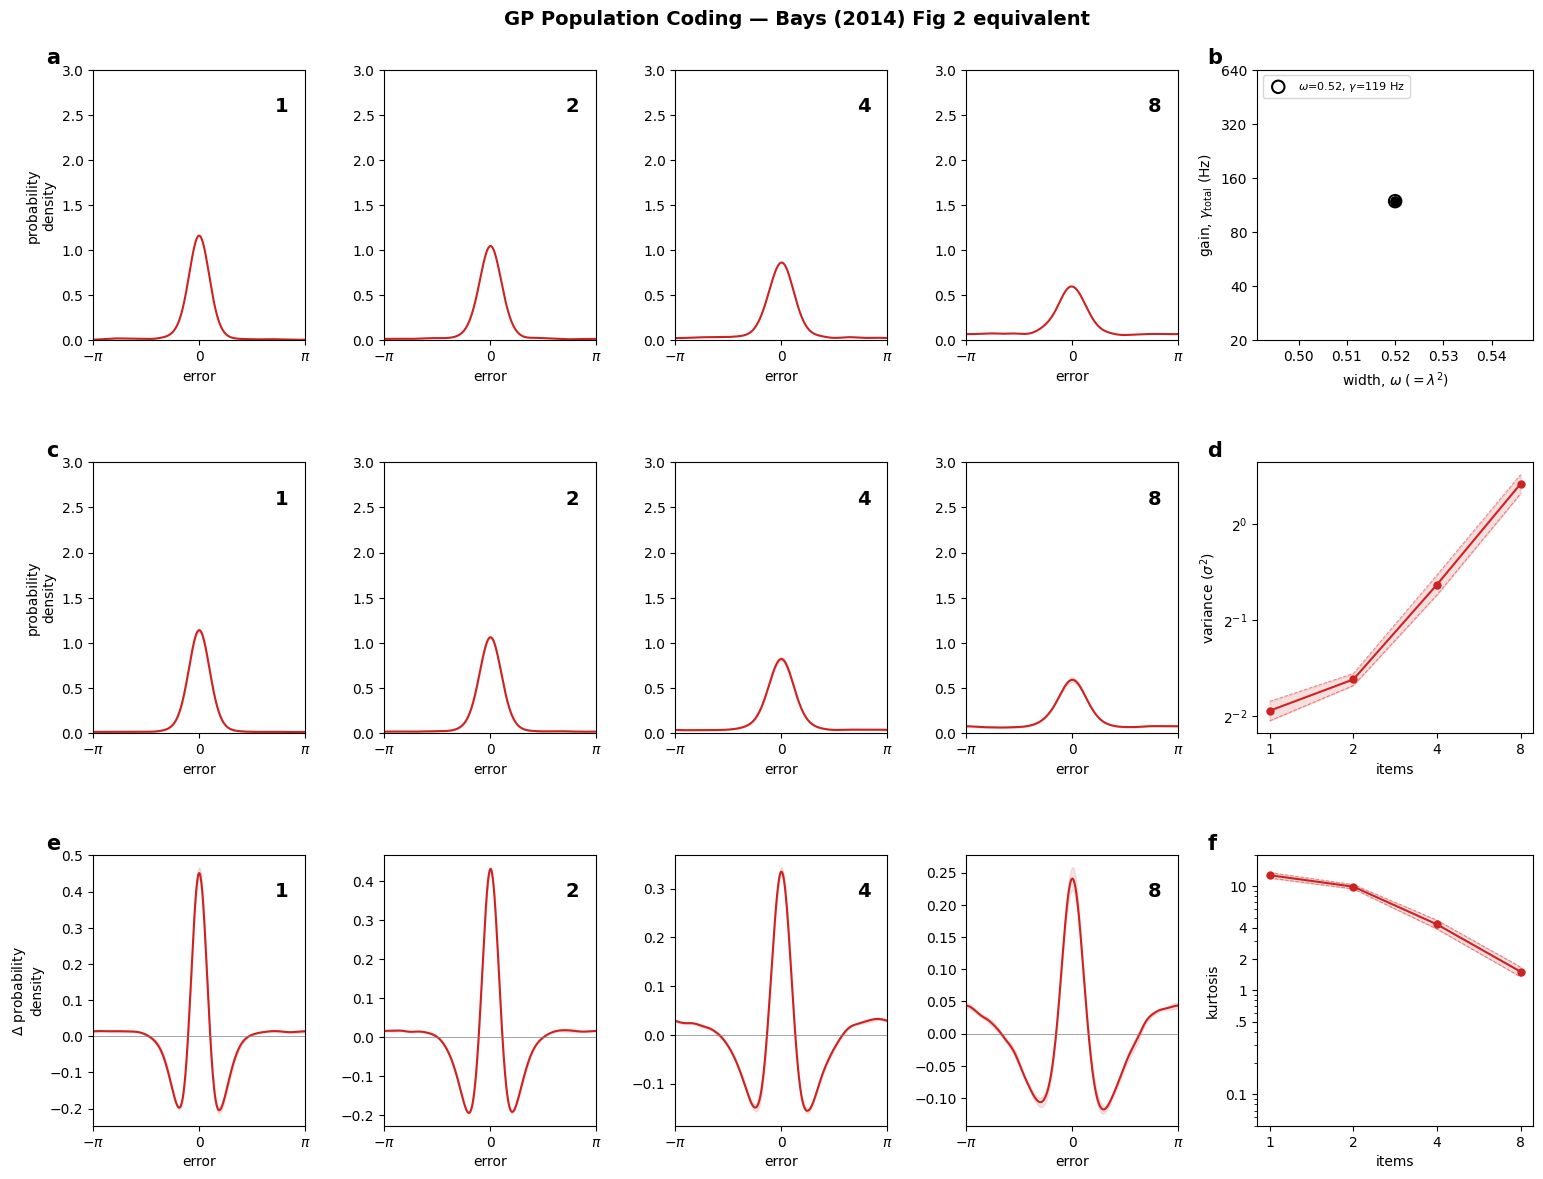

In [13]:
RED = '#CC2222'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, len(SET_SIZES)+1,
    width_ratios=[1]*len(SET_SIZES)+[1.3],
    hspace=0.45, wspace=0.35, left=0.06, right=0.96, bottom=0.05, top=0.93)

# === Row 1: Panel a (representative seed — model error distribution) ===
rep = all_seeds[0]
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[0, i])
    err = rep[N]['errors']
    density = vonmises_kde(err, theta_smooth, kappa=KAPPA_PANELS_AC)
    ax.plot(theta_smooth, density, color=RED, lw=1.5)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel('probability\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{a}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Panel b: per-seed ω and γ (actual values)
ax_b = fig.add_subplot(gs[0, len(SET_SIZES)])
omega_used = LAMBDA_BASE ** 2              # ω = λ² (corrected)
gamma_used = GAMMA * M                     # total gain
ax_b.scatter([omega_used]*N_SEEDS, [gamma_used]*N_SEEDS,
             s=40, c='k', zorder=3, alpha=0.6)
ax_b.scatter([omega_used], [gamma_used], s=80, facecolors='none',
             edgecolors='k', lw=1.5, zorder=4,
             label=f'$\\omega$={omega_used:.2f}, $\\gamma$={gamma_used:.0f} Hz')
ax_b.set_xlabel(r'width, $\omega\;(= \lambda^2)$')
ax_b.set_ylabel(r'gain, $\gamma_{\mathrm{total}}$ (Hz)')
ax_b.set_yscale('log', base=2); ax_b.set_ylim(20, 640)
ax_b.set_yticks([20,40,80,160,320,640])
ax_b.set_yticklabels(['20','40','80','160','320','640'])
ax_b.legend(fontsize=8, loc='upper left')
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Row 2: Panel c (group mean error distribution) + Panel d (variance) ===
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[1, i])
    seed_kdes = []
    for sd in all_seeds:
        kde_s = vonmises_kde(sd[N]['errors'], theta_smooth, kappa=KAPPA_PANELS_AC)
        seed_kdes.append(kde_s)
    seed_kdes = np.array(seed_kdes)
    kde_mean = np.mean(seed_kdes, axis=0)
    kde_se = (np.std(seed_kdes, axis=0, ddof=1) / np.sqrt(len(seed_kdes))
              if len(seed_kdes) > 1 else np.zeros_like(kde_mean))
    ax.plot(theta_smooth, kde_mean, color=RED, lw=1.5)
    ax.fill_between(theta_smooth, kde_mean - kde_se, kde_mean + kde_se,
                    color=RED, alpha=0.12)
    ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, 3)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel('probability\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{c}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# Panel d: variance vs items (log-log) — σ² = −2 log|m̄₁|
ax_d = fig.add_subplot(gs[1, len(SET_SIZES)])
ns = np.array(SET_SIZES, dtype=float)
vm_vals = [summary[N]['var_mean'] for N in SET_SIZES]
vse_vals = [summary[N]['var_se'] for N in SET_SIZES]
ax_d.plot(ns, vm_vals, 'o-', color=RED, lw=1.5, ms=5)
ax_d.fill_between(ns, np.array(vm_vals)-np.array(vse_vals),
                   np.array(vm_vals)+np.array(vse_vals), color=RED, alpha=0.15)
ax_d.plot(ns, np.array(vm_vals)-np.array(vse_vals), '--', color=RED, lw=0.7, alpha=0.5)
ax_d.plot(ns, np.array(vm_vals)+np.array(vse_vals), '--', color=RED, lw=0.7, alpha=0.5)
ax_d.set_xscale('log', base=2); ax_d.set_yscale('log', base=2)
ax_d.set_xticks(SET_SIZES); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items'); ax_d.set_ylabel(r'variance ($\sigma^2$)')
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

# === Row 3: Panel e (deviation from von Mises) + Panel f (kurtosis) ===
for i, N in enumerate(SET_SIZES):
    ax = fig.add_subplot(gs[2, i])
    all_err = np.concatenate([sd[N]['errors'] for sd in all_seeds])
    rho1_e = np.abs(np.mean(np.exp(1j * all_err)))
    kappa_e = _estimate_von_mises_kappa(max(rho1_e, 1e-6))
    vm_ref = vonmises.pdf(theta_smooth, kappa_e)
    emp_kde = vonmises_kde(all_err, theta_smooth, kappa=KAPPA_PANEL_E)
    dev_smooth = emp_kde - vm_ref
    ax.plot(theta_smooth, dev_smooth, color=RED, lw=1.5)
    seed_devs = []
    for sd in all_seeds:
        e_s = sd[N]['errors']
        rho1_s = np.abs(np.mean(np.exp(1j * e_s)))
        kappa_s = _estimate_von_mises_kappa(max(rho1_s, 1e-6))
        vm_s = vonmises.pdf(theta_smooth, kappa_s)
        emp_s = vonmises_kde(e_s, theta_smooth, kappa=KAPPA_PANEL_E)
        seed_devs.append(emp_s - vm_s)
    seed_devs = np.array(seed_devs)
    if N_SEEDS > 1:
        dev_se = np.std(seed_devs, axis=0, ddof=1) / np.sqrt(N_SEEDS)
    else:
        dev_se = np.zeros_like(dev_smooth)
    ax.fill_between(theta_smooth, dev_smooth-dev_se, dev_smooth+dev_se,
                    color=RED, alpha=0.12)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax.set_xlabel('error')
    ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right')
    if i == 0:
        ax.set_ylabel(r'$\Delta$ probability' + '\ndensity')
        ax.text(-0.22, 1.08, r'$\mathbf{e}$', transform=ax.transAxes,
                fontsize=15, fontweight='bold', va='top')

# --- Panel f: kurtosis (matching Bays log-scale y-axis) ---
ax_f = fig.add_subplot(gs[2, len(SET_SIZES)])
km = [summary[N]['kurt_mean'] for N in SET_SIZES]
kse = [summary[N]['kurt_se'] for N in SET_SIZES]
ax_f.plot(ns, km, 'o-', color=RED, lw=1.5, ms=5)
ax_f.fill_between(ns, np.array(km)-np.array(kse),
                   np.array(km)+np.array(kse), color=RED, alpha=0.15)
ax_f.plot(ns, np.array(km)-np.array(kse), '--', color=RED, lw=0.7, alpha=0.5)
ax_f.plot(ns, np.array(km)+np.array(kse), '--', color=RED, lw=0.7, alpha=0.5)
ax_f.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax_f.set_xscale('log', base=2)
# Match Bays's y-axis: log scale with ticks at 0.1, 0.5, 1, 2, 4, 10
ax_f.set_yscale('log')
ax_f.set_ylim(0.05, 20)
ax_f.set_yticks([0.1, 0.5, 1, 2, 4, 10])
ax_f.set_yticklabels(['0.1', '.5', '1', '2', '4', '10'])
ax_f.set_xticks(SET_SIZES); ax_f.set_xticklabels([str(n) for n in SET_SIZES])
ax_f.set_xlabel('items'); ax_f.set_ylabel('kurtosis')
ax_f.text(-0.18, 1.08, r'$\mathbf{f}$', transform=ax_f.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding \u2014 Bays (2014) Fig 2 equivalent',
             fontsize=14, fontweight='bold')
plt.savefig('bays_fig2_corrected.png', dpi=150, bbox_inches='tight')
plt.show()